In [3]:
  
import torch
from matplotlib import pyplot as plt
import numpy as np
device = 'cpu'
ckpt    = torch.load("ggn_lanczos.pt", map_location=device)
ggn_eigvals = ckpt["eigvals"].to(torch.float32).to(device)
ggn_max = ggn_eigvals.max()
ggn_eigvals /=ggn_eigvals.max()
ggn_eigvecs = ckpt["eigvecs"].to(torch.float32).to(device)

device = 'cpu'
ckpt    = torch.load("fisher_lanczos.pt", map_location=device)
fisher_eigvals = ckpt["eigvals"].to(torch.float32).to(device)
fisher_max = fisher_eigvals.max()
fisher_eigvals /=fisher_eigvals.max()
fisher_eigvecs = ckpt["eigvecs"].to(torch.float32).to(device)



eigvals_dict = torch.load("fisher_block_eigvals.pt", weights_only=False)

# concatenate all blocks into one array, sorted descending
all_eigvals = np.concatenate([v.numpy() for v in eigvals_dict.values()])
fisher_block_max = np.max(all_eigvals)
fisher_block_eigvals = np.sort(all_eigvals)[::-1]/np.max(all_eigvals)

ckpt    = torch.load("symo_eig.pt", map_location=device)
symo_eigvals = np.array(ckpt["eigvals"].to(torch.float32).to(device))[::-1]
symo_max = symo_eigvals.max()
symo_eigvals /=symo_eigvals.max()


device = 'cpu'
ckpt    = torch.load("symo_eig_block.pt", map_location=device)
symo_block_eigvals = np.sort(ckpt["eigvals"].to(torch.float32).to(device))[::-1]
symo_block_max = symo_block_eigvals.max()
symo_block_eigvals /=symo_block_eigvals.max()


device = 'cpu'
ckpt    = torch.load("symo_eig_surr_block.pt", map_location=device)
symo_block_surr_eigvals = np.sort(ckpt["eigvals"].to(torch.float32).to(device))[::-1]
symo_block_surr_max = symo_block_surr_eigvals.max()
symo_block_surr_eigvals /=symo_block_surr_eigvals.max()






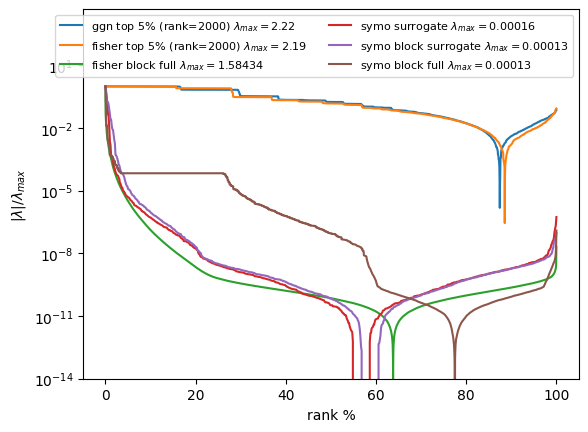

In [4]:
plt.plot(np.linspace(0,100,len(np.abs(ggn_eigvals))),np.abs(ggn_eigvals),label=r'ggn top 5% (rank=2000) $\lambda_{max}=$'+str(np.around(float(ggn_max),2)))
plt.plot(np.linspace(0,100,len(np.abs(fisher_eigvals))),np.abs(fisher_eigvals),label=r'fisher top 5% (rank=2000) $\lambda_{max}=$'+str(np.around(float(fisher_max),2)))
plt.plot(np.linspace(0,100,len(fisher_block_eigvals)),np.abs(fisher_block_eigvals),label= r'fisher block full $\lambda_{max}=$'+str(np.around(fisher_block_max,5)))
plt.plot(np.linspace(0,100,len(np.abs(symo_eigvals))),np.abs(symo_eigvals),label =r'symo surrogate $\lambda_{max}=$'+str(np.around(symo_max,5)))
plt.plot(np.linspace(0,100,len(symo_block_surr_eigvals)),np.abs(symo_block_surr_eigvals),label= r'symo block surrogate $\lambda_{max}=$'+str(np.around(symo_block_surr_max,5)))
plt.plot(np.linspace(0,100,len(symo_block_eigvals)),np.abs(symo_block_eigvals),label= r'symo block full $\lambda_{max}=$'+str(np.around(symo_block_max,5)))
plt.yscale('log')
plt.ylabel(r'$|\lambda|/\lambda_{max}$')
plt.xlabel('rank %')
plt.legend(fontsize=8,ncol=2)
plt.ylim(1e-14,5e3)
plt.show()

In [14]:
  
import torch
from matplotlib import pyplot as plt
import numpy as np
symo_block = torch.load("symo_eig_block.pt", weights_only=False)


In [15]:
len(symo_block['eigvals'])

44426